In [1]:
# --- Basis- und Datenanalyse ---
import numpy as np           # Numerische Berechnungen
import pandas as pd          # Datenanalyse und -manipulation

# --- Rasterdatenverarbeitung ---
import rasterio              # Lesen/Schreiben von Rasterdaten

# --- Machine Learning & Clustering ---
from minisom import MiniSom  # Self-Organizing Maps
from sklearn.preprocessing import StandardScaler  # Daten-Standardisierung
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score  # Cluster-Validierung
from sklearn_extra.cluster import KMedoids        # KMedoids-Clustering
from scipy.spatial.distance import cdist          # Distanzberechnungen

# --- Visualisierung ---
import matplotlib.pyplot as plt  # Plotten

# --- Fortschrittsbalken ---
from tqdm import tqdm            # Fortschrittsanzeigen für Schleifen


In [2]:

# 1. Rasterdaten laden (wie bei dir)
firemetrics_dir = r"A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035"
files = [
    f"{firemetrics_dir}/fire_return_interval_dual.tif",
    f"{firemetrics_dir}/fire_season_length_final.tif",
    f"{firemetrics_dir}/MBA_MeanFractionBurned_3km_2000-2025.tif",
    f"{firemetrics_dir}/MBA_burned_area_sum_max_final.tif"
]

with rasterio.open(files[0]) as src:
    fri_classic = src.read(2)
    profile = src.profile
    transform = src.transform

with rasterio.open(files[1]) as src:
    season_length = src.read(1)

with rasterio.open(files[2]) as src:
    mean_fraction_burned = src.read(1)

with rasterio.open(files[3]) as src:
    max_burned_area = src.read(2)

stack = np.stack([fri_classic, season_length, mean_fraction_burned, max_burned_area])
mask = ~np.any(np.isnan(stack), axis=0)
rows, cols = np.where(mask)
data = stack[:, rows, cols].T  # shape: (n_samples, n_features)


In [3]:

# 2. Standardisierung
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)


In [4]:

# 3. SOM trainieren
n_samples = data_scaled.shape[0]
m = int(5 * np.sqrt(n_samples))
xdim = int(np.floor(np.sqrt(m)))
ydim = int(np.ceil(m / xdim))

som = MiniSom(xdim, ydim, data_scaled.shape[1], sigma=1.0, learning_rate=0.5, neighborhood_function='gaussian', random_seed=42)
som.train(data_scaled, 3500, verbose=True)


 [ 3500 / 3500 ] 100% - 0:00:00 left 

a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\minisom.py:513: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)



 quantization error: 0.1760150023103817


In [5]:
#  prüfen, ob alle SOM-Gewichte finite Werte haben:
#  Wenn das False ergibt, ist alles ok.

import numpy as np
print(np.any(~np.isfinite(som.get_weights())))

False


In [6]:

# 4. Codebook-Vektoren extrahieren
codes = som.get_weights().reshape(-1, data_scaled.shape[1])


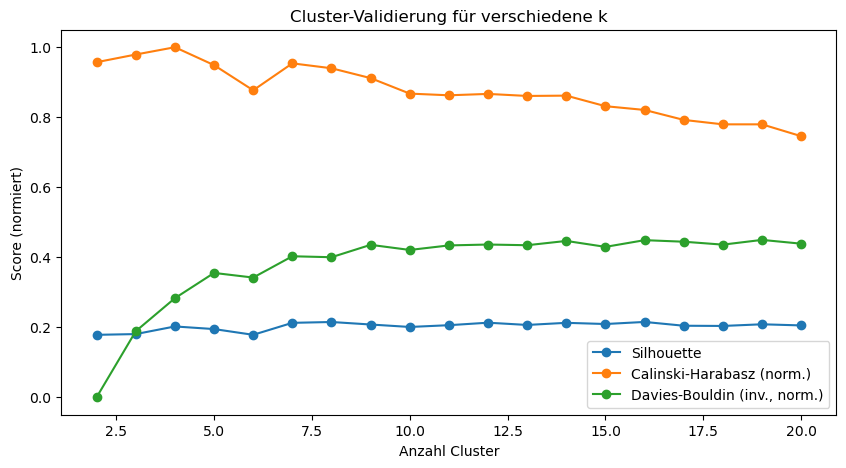

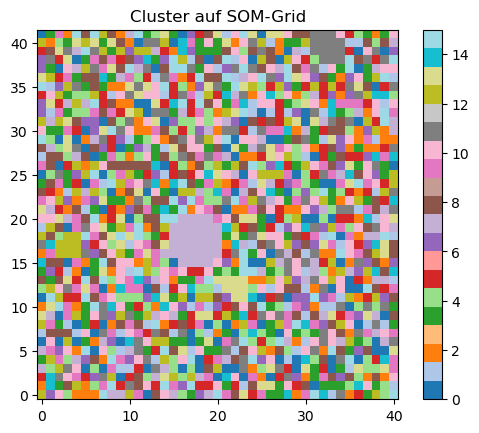

In [9]:
# 5. Cluster-Validierung (Silhouette, CH, DBI) für verschiedene k mit KMedoids (wie PAM in R)
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, pairwise_distances
diss_matrix = pairwise_distances(codes, metric='euclidean')

sil_scores = []
ch_scores = []
db_scores = []
k_range = range(2, 21)
for k in k_range:
    kmed = KMedoids(n_clusters=k, metric='precomputed', random_state=42).fit(diss_matrix)
    labels = kmed.labels_
    sil_scores.append(silhouette_score(diss_matrix, labels, metric='precomputed'))
    ch_scores.append(calinski_harabasz_score(codes, labels))
    db_scores.append(davies_bouldin_score(codes, labels))

plt.figure(figsize=(10,5))
plt.plot(k_range, sil_scores, label='Silhouette', marker='o')
plt.plot(k_range, ch_scores/np.max(ch_scores), label='Calinski-Harabasz (norm.)', marker='o')
plt.plot(k_range, (np.max(db_scores)-db_scores)/np.max(db_scores), label='Davies-Bouldin (inv., norm.)', marker='o')
plt.xlabel("Anzahl Cluster")
plt.ylabel("Score (normiert)")
plt.legend()
plt.title("Cluster-Validierung für verschiedene k")
plt.show()

# Visualisierung auf SOM-Grid
xdim, ydim, nvar = som.get_weights().shape
grid_labels = cluster_labels.reshape(xdim, ydim)
plt.imshow(grid_labels.T, origin='lower', cmap='tab20')
plt.title("Cluster auf SOM-Grid")
plt.colorbar()
plt.show()


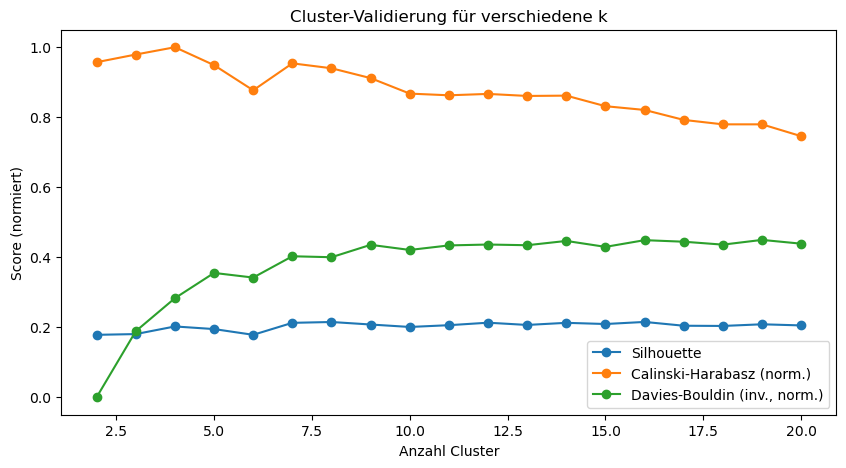

Optimale Clusterzahl (Silhouette): 16


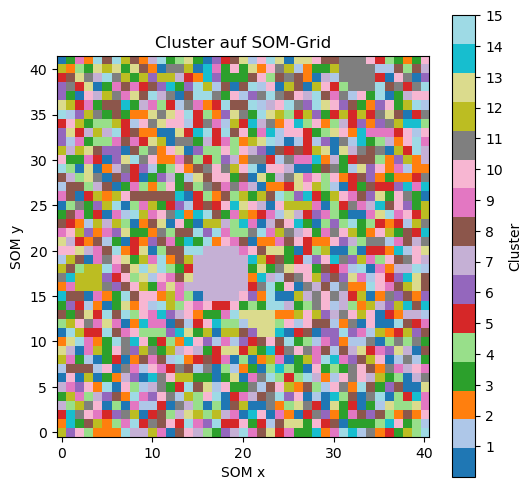

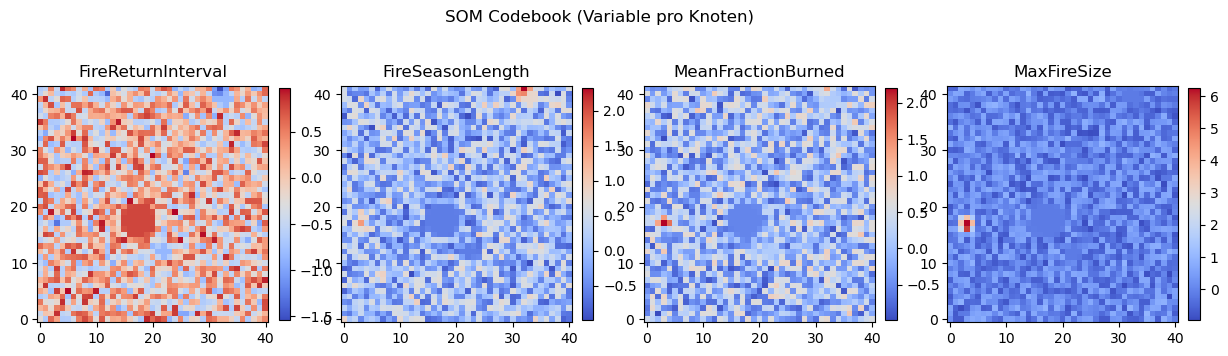

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, pairwise_distances

def som_cluster_inspection_kmedoids(som, codes, k_range=range(2, 21), plot_grid=True, var_names=None):
    # 1. Distanzen berechnen
    diss_matrix = pairwise_distances(codes, metric='euclidean')
    
    # 2. Scores initialisieren
    sil_scores = []
    ch_scores = []
    db_scores = []
    cluster_labels_list = []
    
    # 3. Für verschiedene k clustern und Scores berechnen
    for k in k_range:
        kmed = KMedoids(n_clusters=k, metric='precomputed', random_state=42).fit(diss_matrix)
        labels = kmed.labels_
        cluster_labels_list.append(labels)
        sil_scores.append(silhouette_score(diss_matrix, labels, metric='precomputed'))
        ch_scores.append(calinski_harabasz_score(codes, labels))
        db_scores.append(davies_bouldin_score(codes, labels))
    
    # 4. Scores plotten
    plt.figure(figsize=(10,5))
    plt.plot(k_range, sil_scores, label='Silhouette', marker='o')
    plt.plot(k_range, ch_scores/np.max(ch_scores), label='Calinski-Harabasz (norm.)', marker='o')
    plt.plot(k_range, (np.max(db_scores)-db_scores)/np.max(db_scores), label='Davies-Bouldin (inv., norm.)', marker='o')
    plt.xlabel("Anzahl Cluster")
    plt.ylabel("Score (normiert)")
    plt.legend()
    plt.title("Cluster-Validierung für verschiedene k")
    plt.show()
    
    # 5. Optimale Clusterzahl bestimmen (max Silhouette)
    optimal_k = k_range[np.argmax(sil_scores)]
    print(f"Optimale Clusterzahl (Silhouette): {optimal_k}")
    
    # 6. Clusterlabels für optimales k
    best_labels = cluster_labels_list[optimal_k_idx]
    
    # 7. Visualisierung auf SOM-Grid (Codebook)
    if plot_grid:
        xdim, ydim, nvar = som.get_weights().shape
        grid_labels = best_labels.reshape(xdim, ydim)
        cmap = plt.get_cmap('tab20', np.max(best_labels)+1)
        plt.figure(figsize=(6,6))
        plt.imshow(grid_labels.T, origin='lower', cmap=cmap)
        plt.colorbar(ticks=range(1, np.max(best_labels)+2), label='Cluster')
        plt.title("Cluster auf SOM-Grid")
        plt.xlabel("SOM x")
        plt.ylabel("SOM y")
        plt.show()
        
        # Optional: Codebook-Visualisierung pro Variable
        if var_names is not None:
            fig, axes = plt.subplots(1, nvar, figsize=(15, 4))
            for i, ax in enumerate(axes):
                im = ax.imshow(som.get_weights()[:,:,i].T, origin='lower', cmap='coolwarm')
                ax.set_title(var_names[i])
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            plt.suptitle("SOM Codebook (Variable pro Knoten)")
            plt.show()
    
    return best_labels

# Beispielaufruf:
var_names = ['FireReturnInterval', 'FireSeasonLength', 'MeanFractionBurned', 'MaxFireSize']
best_labels = som_cluster_inspection_kmedoids(som, codes, k_range=range(2,21), plot_grid=True, var_names=var_names)

In [12]:
# Mappe jeden Datenpunkt auf einen SOM-Knoten und dann auf einen Cluster
win_map = np.array([som.winner(x) for x in data_scaled])
som_indices = win_map[:,0] * ydim + win_map[:,1]
pixel_clusters = cluster_labels[som_indices]

cluster_raster = np.full(fri_classic.shape, np.nan)
cluster_raster[rows, cols] = pixel_clusters + 1  # Cluster-IDs ab 1

import rasterio
profile = rasterio.open(files[0]).profile
profile.update(dtype='float32', count=1)
with rasterio.open(f"{firemetrics_dir}/FireMetrics_SOM_Cluster_latest.tif", "w", **profile) as dst:
    dst.write(cluster_raster.astype('float32'), 1)

# Ausgabe der Cluster-Informationen
unique_clusters = np.unique(cluster_raster[~np.isnan(cluster_raster)])
print(f"Anzahl der Cluster: {len(unique_clusters)}")
print(f"Cluster-IDs: {unique_clusters}")
#anzahl werte je cluster
cluster_counts = pd.Series(pixel_clusters).value_counts().sort_index()
print(cluster_counts)

In [ ]:

# 7. Clustering mit optimal_k
kmed = KMedoids(n_clusters=optimal_k, metric='precomputed', random_state=42).fit(diss_matrix)
cluster_labels = kmed.labels_

# 8. Mappe jeden Datenpunkt auf einen SOM-Knoten und dann auf einen Cluster
win_map = np.array([som.winner(x) for x in data_scaled])
som_indices = win_map[:,0] * ydim + win_map[:,1]
pixel_clusters = cluster_labels[som_indices]

# 9. Cluster zurück auf Raster schreiben
cluster_raster = np.full(fri_classic.shape, np.nan)
cluster_raster[rows, cols] = pixel_clusters + 1  # Cluster-IDs ab 1

# 10. Speichern
profile.update(dtype='float32', count=1)
with rasterio.open(f"{firemetrics_dir}/FireMetrics_SOM_Cluster_py.tif", "w", **profile) as dst:
    dst.write(cluster_raster.astype('float32'), 1)

print("Cluster-Raster gespeichert!")
# Ausgabe der Cluster-Informationen
unique_clusters = np.unique(cluster_raster[~np.isnan(cluster_raster)])
print(f"Anzahl der Cluster: {len(unique_clusters)}")
print(f"Cluster-IDs: {unique_clusters}")
#anzahl werte je cluster
cluster_counts = pd.Series(pixel_clusters).value_counts().sort_index()
print(cluster_counts)

### Validierung der Clusterlösung (frei nach Galizia et al. 2021)

Ablauf:

- Wiederhole das Clustering auf zufälligen 70%-Subsamples deiner Daten.
- Vergleiche die Clusterlabels des Subsamples mit denen der Gesamtlösung (auf den Subsample-Indizes).
- Berechne die Übereinstimmung (Accuracy) und Cohen’s Kappa.
- Wiederhole das Ganze z.B. 1000-mal und berechne den Mittelwert.

In [ ]:
# from sklearn.metrics import accuracy_score, cohen_kappa_score
# from sklearn.utils import resample
# from sklearn.cluster import AgglomerativeClustering


# n_iter = 1000
# accs = []
# kappas = []

# # Gesamtlösung
# clustering_full = AgglomerativeClustering(n_clusters=optimal_k).fit(codes)
# labels_full = clustering_full.labels_

# rng = np.random.default_rng(42)
# for _ in range(n_iter):
#     idx = rng.choice(len(codes), int(0.7 * len(codes)), replace=False)
#     codes_sub = codes[idx]
#     clustering_sub = AgglomerativeClustering(n_clusters=10).fit(codes_sub)
#     labels_sub = clustering_sub.labels_
#     # Vergleiche nur auf Subsample-Indizes
#     accs.append(accuracy_score(labels_full[idx], labels_sub))
#     kappas.append(cohen_kappa_score(labels_full[idx], labels_sub))

# print(f"Mittlere Accuracy: {np.mean(accs):.3f}")
# print(f"Mittlerer Cohen's Kappa: {np.mean(kappas):.3f}")

Mittlere Accuracy: 0.077
Mittlerer Cohen's Kappa: 0.003


In [15]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import accuracy_score, cohen_kappa_score
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "4"  # oder eine andere kleine Zahl

cluster_methods = {
    "KMeans": lambda k: KMeans(n_clusters=k, n_init="auto", random_state=42),
    "Agglomerative": lambda k: AgglomerativeClustering(n_clusters=k),
    "KMedoids": lambda k: KMedoids(n_clusters=k, random_state=42)
}

results = {}

for method_name, method in cluster_methods.items():
    print(f"\nValidierung für: {method_name}")
    for n_clusters in range(10, 2, -1):
        accs = []
        kappas = []
        clustering_full = method(n_clusters).fit(codes)
        labels_full = clustering_full.labels_
        rng = np.random.default_rng(42)
        for _ in range(100):  # Für schnellen Test, ggf. auf 1000 erhöhen
            idx = rng.choice(len(codes), int(0.7 * len(codes)), replace=False)
            codes_sub = codes[idx]
            clustering_sub = method(n_clusters).fit(codes_sub)
            labels_sub = clustering_sub.labels_
            accs.append(accuracy_score(labels_full[idx], labels_sub))
            kappas.append(cohen_kappa_score(labels_full[idx], labels_sub))
        mean_acc = np.mean(accs)
        mean_kappa = np.mean(kappas)
        print(f"n_clusters={n_clusters}: Accuracy={mean_acc:.3f}, Kappa={mean_kappa:.3f}")
        results[(method_name, n_clusters)] = (mean_acc, mean_kappa)

# DBSCAN separat, da keine n_clusters-Variable
print("\nValidierung für: DBSCAN")
accs = []
kappas = []
dbscan = DBSCAN(eps=0.5, min_samples=5)
clustering_full = dbscan.fit(codes)
labels_full = clustering_full.labels_
rng = np.random.default_rng(42)
for _ in range(100):
    idx = rng.choice(len(codes), int(0.7 * len(codes)), replace=False)
    codes_sub = codes[idx]
    clustering_sub = DBSCAN(eps=0.5, min_samples=5).fit(codes_sub)
    labels_sub = clustering_sub.labels_
    # Nur vergleichen, wenn Clusteranzahl gleich ist und keine -1 (Noise) vorkommt
    if (len(np.unique(labels_full[idx])) == len(np.unique(labels_sub))) and (-1 not in labels_sub):
        accs.append(accuracy_score(labels_full[idx], labels_sub))
        kappas.append(cohen_kappa_score(labels_full[idx], labels_sub))
if accs:
    print(f"DBSCAN: Accuracy={np.mean(accs):.3f}, Kappa={np.mean(kappas):.3f}")
    results[("DBSCAN", None)] = (np.mean(accs), np.mean(kappas))
else:
    print("DBSCAN: Keine vergleichbaren Clusterlösungen gefunden.")


Validierung für: KMeans


a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.p

n_clusters=10: Accuracy=0.102, Kappa=0.002


a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.p

n_clusters=9: Accuracy=0.123, Kappa=0.013


...

n_clusters=5: Accuracy=0.217, Kappa=0.021


a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.p

n_clusters=4: Accuracy=0.250, Kappa=-0.000


a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.p

n_clusters=3: Accuracy=0.328, Kappa=-0.007

Validierung für: Agglomerative
n_clusters=10: Accuracy=0.101, Kappa=-0.005
n_clusters=9: Accuracy=0.121, Kappa=-0.001
n_clusters=8: Accuracy=0.141, Kappa=0.004
n_clusters=7: Accuracy=0.152, Kappa=-0.006
n_clusters=6: Accuracy=0.183, Kappa=0.016
n_clusters=5: Accuracy=0.212, Kappa=0.013
n_clusters=4: Accuracy=0.253, Kappa=-0.017
n_clusters=3: Accuracy=0.334, Kappa=-0.017

Validierung für: KMedoids
n_clusters=10: Accuracy=0.122, Kappa=0.024
n_clusters=9: Accuracy=0.138, Kappa=0.031
n_clusters=8: Accuracy=0.156, Kappa=0.035
n_clusters=7: Accuracy=0.164, Kappa=0.025
n_clusters=6: Accuracy=0.181, Kappa=0.017
n_clusters=5: Accuracy=0.272, Kappa=0.089
n_clusters=4: Accuracy=0.347, Kappa=0.129
n_clusters=3: Accuracy=0.535, Kappa=0.303

Validierung für: DBSCAN
DBSCAN: Keine vergleichbaren Clusterlösungen gefunden.


In [16]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn_extra.cluster import KMedoids

# Annahme: codes = SOM-Codebook-Vektoren, pixel_clusters = Mapping auf Raster, rows, cols, fri_classic.shape, profile sind definiert

cluster_methods = {
    "KMeans": lambda k: KMeans(n_clusters=k, n_init=10, random_state=42),
    "Agglomerative": lambda k: AgglomerativeClustering(n_clusters=k),
    "KMedoids": lambda k: KMedoids(n_clusters=k, random_state=42)
}

for method_name, method in cluster_methods.items():
    for n_clusters in range(2, 6):
        # Clustering auf Codebook
        clustering = method(n_clusters).fit(codes)
        cluster_labels = clustering.labels_
        # Mapping auf Rasterdaten
        win_map = np.array([som.winner(x) for x in data_scaled])
        xdim, ydim, _ = som.get_weights().shape
        som_indices = win_map[:,0] * ydim + win_map[:,1]
        pixel_clusters = cluster_labels[som_indices]
        # Raster schreiben
        cluster_raster = np.full(fri_classic.shape, np.nan)
        cluster_raster[rows, cols] = pixel_clusters + 1  # Cluster-IDs ab 1
        profile.update(dtype='float32', count=1)
        outname = f"{firemetrics_dir}/Cluster_{method_name}_{n_clusters}.tif"
        with rasterio.open(outname, "w", **profile) as dst:
            dst.write(cluster_raster.astype('float32'), 1)
        print(f"Gespeichert: {outname}")

# DBSCAN separat (keine feste Clusterzahl)
dbscan = DBSCAN(eps=0.5, min_samples=5)
cluster_labels = dbscan.fit_predict(codes)
win_map = np.array([som.winner(x) for x in data_scaled])
xdim, ydim, _ = som.get_weights().shape
som_indices = win_map[:,0] * ydim + win_map[:,1]
pixel_clusters = cluster_labels[som_indices]
cluster_raster = np.full(fri_classic.shape, np.nan)
cluster_raster[rows, cols] = pixel_clusters  # DBSCAN: -1 = Noise
profile.update(dtype='float32', count=1)
outname = f"{firemetrics_dir}/Cluster_DBSCAN.tif"
with rasterio.open(outname, "w", **profile) as dst:
    dst.write(cluster_raster.astype('float32'), 1)
print(f"Gespeichert: {outname}")

a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_KMeans_2.tif


a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_KMeans_3.tif


a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_KMeans_4.tif


a:\_BioGeo\butzerfe\miniforge3\envs\wilde\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_KMeans_5.tif
Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_Agglomerative_2.tif
Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_Agglomerative_3.tif
Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_Agglomerative_4.tif
Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_Agglomerative_5.tif
Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_KMedoids_2.tif
Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_KMedoids_3.tif
Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_KMedoids_4.tif
Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_KMedoids_5.tif
Gespeichert: A:/_BioGeo/butzerfe/thesis/_Runs/01_Fire_Metrics/MBA_3km_3035/Cluster_DBSCAN.tif


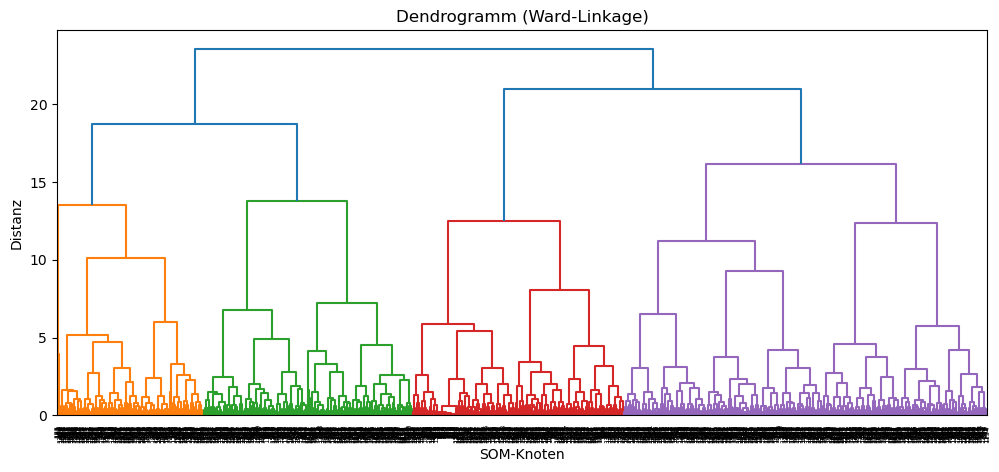

Clusterlabels für 5 Cluster berechnet.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering

# Annahme: codes = SOM-Codebook-Vektoren

# 1. Agglomerative Clustering mit 13 Clustern
clustering = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_13 = clustering.fit_predict(codes)

# 2. Dendrogramm plotten (Ward-Linkage)
Z = linkage(codes, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=30)
plt.title("Dendrogramm (Ward-Linkage)")
plt.xlabel("SOM-Knoten")
plt.ylabel("Distanz")
plt.show()

# 3. Nachträglich andere Clusterzahl wählen (z.B. 8)
n_clusters_new = 5
labels_new = fcluster(Z, n_clusters_new, criterion='maxclust') - 1  # Cluster-IDs ab 0

print(f"Clusterlabels für {n_clusters_new} Cluster berechnet.")